In [1]:
import uproot
import numpy as np
import utils
from tqdm import tqdm
import importlib
import matplotlib.pyplot as plt
import drawing

In [2]:
# base_path = "/eos/user/l/ligerlac/cicada_data/skimmed-2025-07-09"
base_path = "../data/skimmed-2025-07-09"

branches = [
    "CICADA2024_CICADAScore",
    "CICADA2025_CICADAScore",
    "axol1tl_v3_AXOScore",
    "axol1tl_v4_AXOScore",
    "PV_npvs",
    "PV_npvsGood",
    "et",
    "is_pure"
]

process_list = [
    "GluGluHToGG",
    "HTo2LongLivedTo4b",
    "TT",
    "VBFHtoTauTau",
    "ZprimeToTauTau",
    "GluGluToTauTau",
    "SingleNeutrino",
    "VBFHto2B",
    "ZB",
    "ZZ",
]


def get_array(proc, var):
    file_name = f"{base_path}/{proc}.root:Events"
    with uproot.open(file_name) as events:
        return events[var].array(library="np")


In [53]:
# load all variables from file
et_dict, is_pure_dict, npv_dict = {}, {}, {}
for proc in ["ZB", "HTo2LongLivedTo4b", "GluGluHToGG", "VBFHto2B", "SUEP", "TT", "SingleNeutrino"]:
    print(f"Loading {proc}...")
    et_dict[proc] = get_array(proc, "et")
    is_pure_dict[proc] = get_array(proc, "is_pure")
    npv_dict[proc] = get_array(proc, "PV_npvsGood")

npv_mask = npv_dict["ZB"] > 10
et_dict["ZB-masked"] = et_dict["ZB"][npv_mask]
npv_dict["ZB-masked"] = npv_dict["ZB"][npv_mask]
is_pure_dict["ZB-masked"] = is_pure_dict["ZB"][npv_mask]

Loading ZB...
Loading HTo2LongLivedTo4b...
Loading GluGluHToGG...
Loading VBFHto2B...
Loading SUEP...
Loading TT...
Loading SingleNeutrino...


In [54]:
# npv reweighting study
npv_arr = range(100)
weights = {}
npv_data = npv_dict["ZB-masked"]

for proc in ["HTo2LongLivedTo4b", "GluGluHToGG", "VBFHto2B", "SUEP", "TT", "SingleNeutrino"]:
    npv_mc = npv_dict[proc]
    weights[proc] = np.zeros_like(npv_mc, dtype=float)
    for npv_ in npv_arr:
        idx_data = npv_data == npv_
        idx_mc = npv_mc == npv_
        w = np.sum(idx_data) / np.sum(idx_mc)
        weights[proc][idx_mc] = w
    weights[proc] = np.array(weights[proc])
    weights[proc][~np.isfinite(weights[proc])] = 0.0


/var/folders/c0/9f43s3c12sn447zr9wy8pp3c0000gn/T/ipykernel_73687/2229020448.py:12: RuntimeWarning: invalid value encountered in scalar divide
  w = np.sum(idx_data) / np.sum(idx_mc)
/var/folders/c0/9f43s3c12sn447zr9wy8pp3c0000gn/T/ipykernel_73687/2229020448.py:12: RuntimeWarning: divide by zero encountered in scalar divide
  w = np.sum(idx_data) / np.sum(idx_mc)


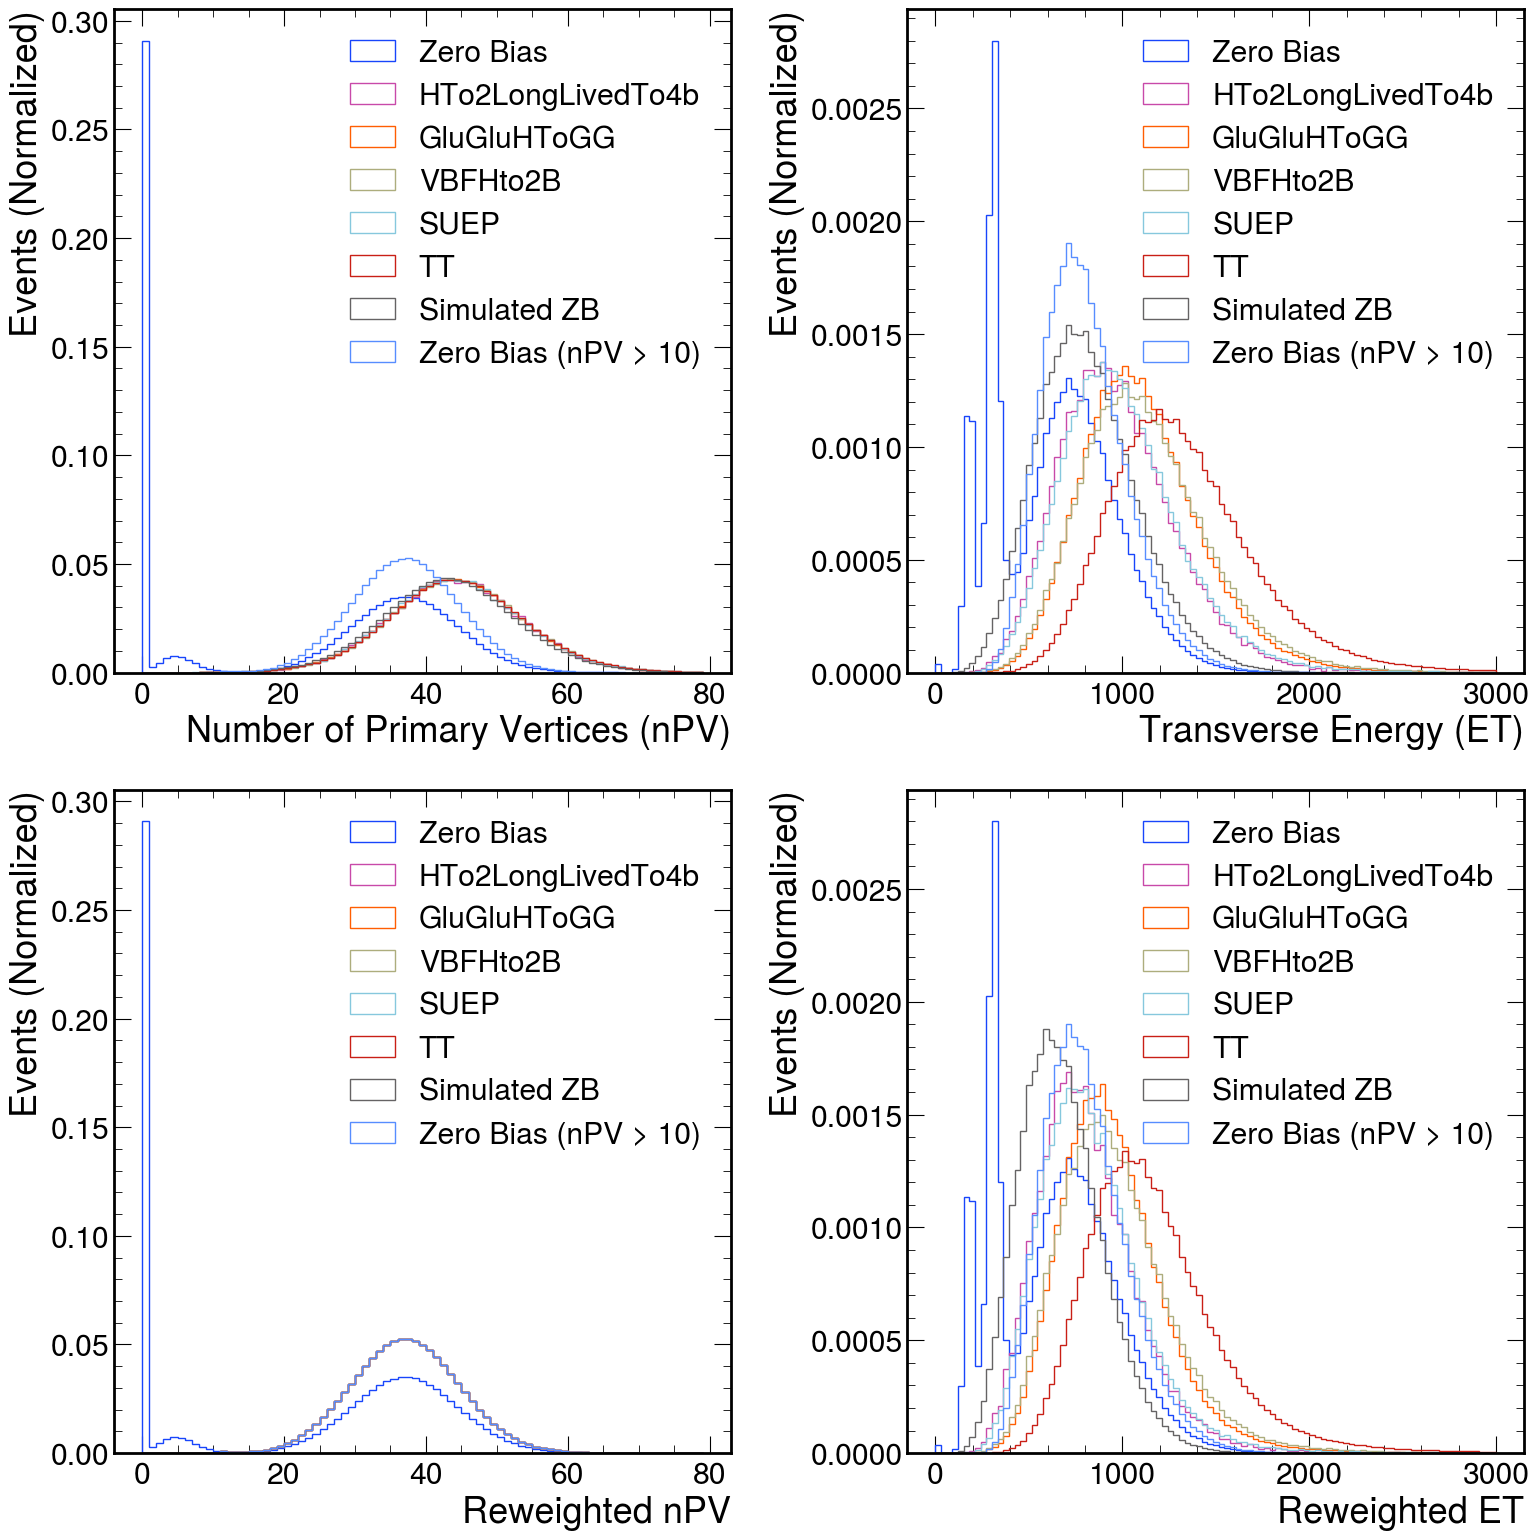

In [5]:
import importlib
import drawing
importlib.reload(drawing)
draw = drawing.Draw(interactive=True)

draw.make_npv_reweighting_plot(
    npv_dict=npv_dict,
    et_dict=et_dict,
    weight_dict=weights,
)

In [6]:
# the order plays a role here!
proc_list = [
    "ZB",
    "SingleNeutrino",
    "HTo2LongLivedTo4b",
    "GluGluHToGG",
    "VBFHto2B",
    "SUEP",
    "TT",
]

cicada_score_dict = {
    proc: get_array(proc, "CICADA2024_CICADAScore") for proc in proc_list
}
cicada_score_dict["ZB-masked"] = cicada_score_dict["ZB"][npv_mask]

axo_score_dict = {
    proc: get_array(proc, "axol1tl_v4_AXOScore") for proc in proc_list
}
axo_score_dict["ZB-masked"] = axo_score_dict["ZB"][npv_mask]

Left legend keyzs: ['ZB', 'ZB-masked', 'SingleNeutrino'], Right legend keys: ['HTo2LongLivedTo4b', 'GluGluHToGG', 'VBFHto2B', 'SUEP', 'TT']


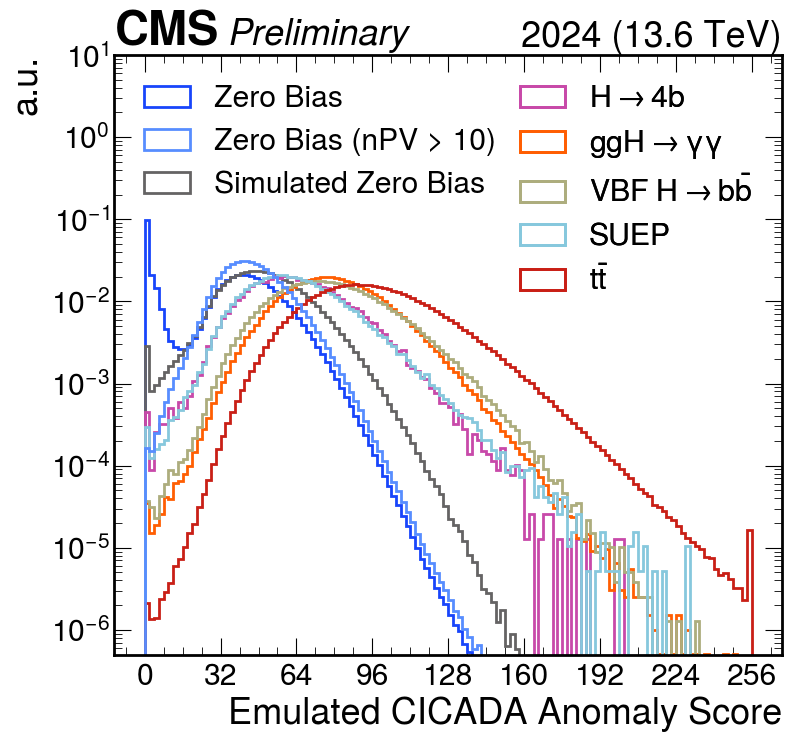

Left legend keyzs: ['ZB', 'ZB-masked', 'SingleNeutrino'], Right legend keys: ['HTo2LongLivedTo4b', 'GluGluHToGG', 'VBFHto2B', 'SUEP', 'TT']


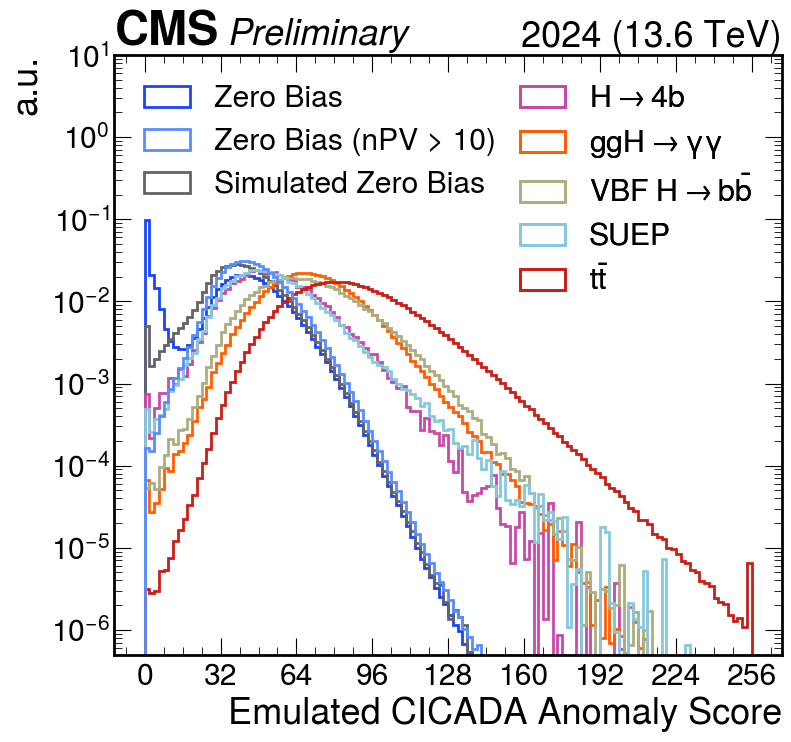

Left legend keyzs: ['ZB', 'ZB-masked', 'SingleNeutrino'], Right legend keys: ['HTo2LongLivedTo4b', 'GluGluHToGG', 'VBFHto2B', 'SUEP', 'TT']


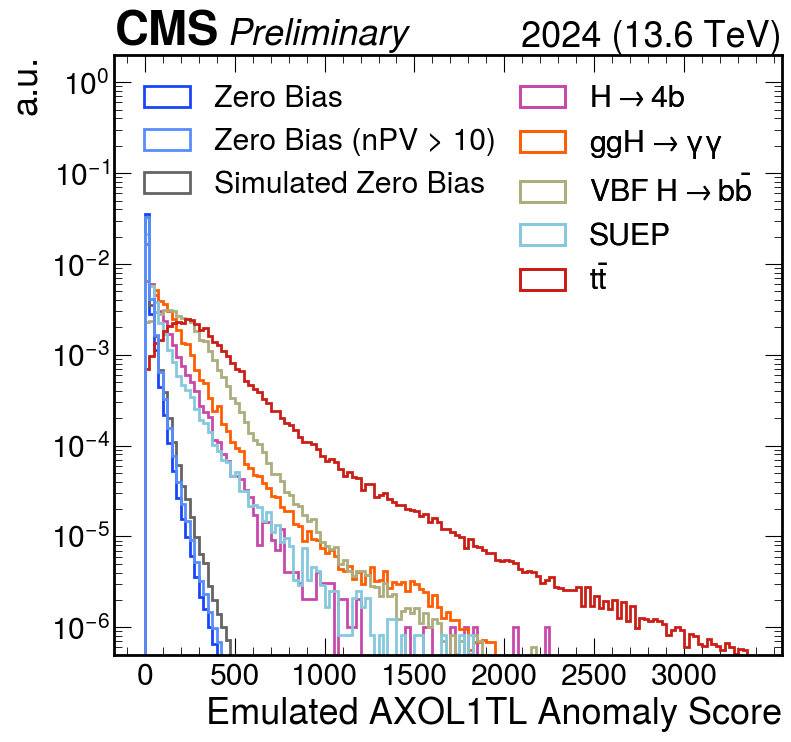

Left legend keyzs: ['ZB', 'ZB-masked', 'SingleNeutrino'], Right legend keys: ['HTo2LongLivedTo4b', 'GluGluHToGG', 'VBFHto2B', 'SUEP', 'TT']


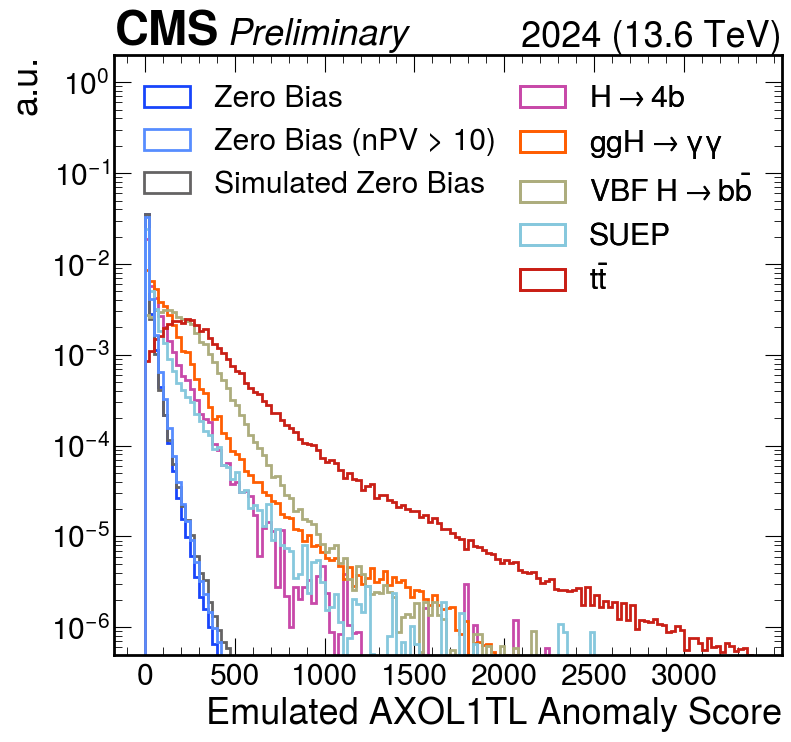

In [72]:
importlib.reload(drawing)
draw = drawing.Draw(interactive=True, output_format="pdf")


draw.plot_anomaly_score_distribution(
    cicada_score_dict.values(),
    labels=list(cicada_score_dict.keys()),
    name="as-dist-cicada",
    xlabel="Emulated CICADA Anomaly Score",
    bins=range(0, 258, 2),
    xticks=range(0, 258, 32),
    left_legend_col=(0, -1, 1),
    y_max=10,
    figsize=(8.5, 8),
)

draw.plot_anomaly_score_distribution(
    cicada_score_dict.values(),
    labels=list(cicada_score_dict.keys()),
    name="as-dist-cicada-rw",
    xlabel="Emulated CICADA Anomaly Score",
    bins=range(0, 258, 2),
    xticks=range(0, 258, 32),
    left_legend_col=(0, -1, 1),
    weights=weights,
    y_max=10,
    figsize=(8.5, 8),
)

draw.plot_anomaly_score_distribution(
    axo_score_dict.values(),
    labels=list(axo_score_dict.keys()),
    name="as-dist-axo",
    xlabel="Emulated AXOL1TL Anomaly Score",
    bins=range(0, 3400, 25),
    xticks=range(0, 3400, 500),
    left_legend_col=(0, -1, 1),
    y_max=2,
    figsize=(8.5, 8),
)

draw.plot_anomaly_score_distribution(
    axo_score_dict.values(),
    labels=list(axo_score_dict.keys()),
    name="as-dist-axo-rw",
    xlabel="Emulated AXOL1TL Anomaly Score",
    bins=range(0, 3400, 25),
    xticks=range(0, 3400, 500),
    left_legend_col=(0, -1, 1),
    y_max=2,
    weights=weights,
    figsize=(8.5, 8),
)

In [36]:
importlib.reload(utils)

bg_labels = ["ZB", "ZB-masked", "SingleNeutrino"]
sig_labels = [l for l in proc_list if l not in bg_labels]

roc_dict_cicada = utils.get_roc_dict(cicada_score_dict, "ZB-masked", sig_labels)
roc_dict_cicada_baseline = utils.get_roc_dict(cicada_score_dict, "SingleNeutrino", sig_labels)

roc_dict_axo = utils.get_roc_dict(axo_score_dict, "ZB-masked", sig_labels)
roc_dict_axo_baseline = utils.get_roc_dict(axo_score_dict, "SingleNeutrino", sig_labels)

In [37]:
roc_dict_cicada_rw = utils.get_roc_dict(cicada_score_dict, "ZB-masked", sig_labels, weight_dict=weights)
roc_dict_cicada_baseline_rw = utils.get_roc_dict(cicada_score_dict, "SingleNeutrino", sig_labels, weight_dict=weights)

roc_dict_axo_rw = utils.get_roc_dict(axo_score_dict, "ZB-masked", sig_labels, weight_dict=weights)
roc_dict_axo_baseline_rw = utils.get_roc_dict(axo_score_dict, "SingleNeutrino", sig_labels, weight_dict=weights)

In [ ]:
cicada_score_dict_pure = {proc: score[is_pure_dict[proc]] for proc, score in cicada_score_dict.items()}
axo_score_dict_pure = {proc: score[is_pure_dict[proc]] for proc, score in axo_score_dict.items()}
weights_pure = {proc: w[is_pure_dict[proc]] for proc, w in weights.items()}

roc_dict_cicada_pure_rw = utils.get_roc_dict(cicada_score_dict_pure, "ZB-masked", sig_labels, weight_dict=weights_pure)
roc_dict_cicada_baseline_pure_rw = utils.get_roc_dict(cicada_score_dict_pure, "SingleNeutrino", sig_labels, weight_dict=weights_pure)

roc_dict_axo_pure_rw = utils.get_roc_dict(axo_score_dict_pure, "ZB-masked", sig_labels, weight_dict=weights_pure)
roc_dict_axo_baseline_pure_rw = utils.get_roc_dict(axo_score_dict_pure, "SingleNeutrino", sig_labels, weight_dict=weights_pure)


Working point VL at rate 1.6 kHz with TPR 0.18
Working point  at rate 1.1 kHz with TPR 0.15
Working point M at rate 0.62 kHz with TPR 0.12
Working point  at rate 0.37 kHz with TPR 0.09
Working point VT at rate 0.25 kHz with TPR 0.08


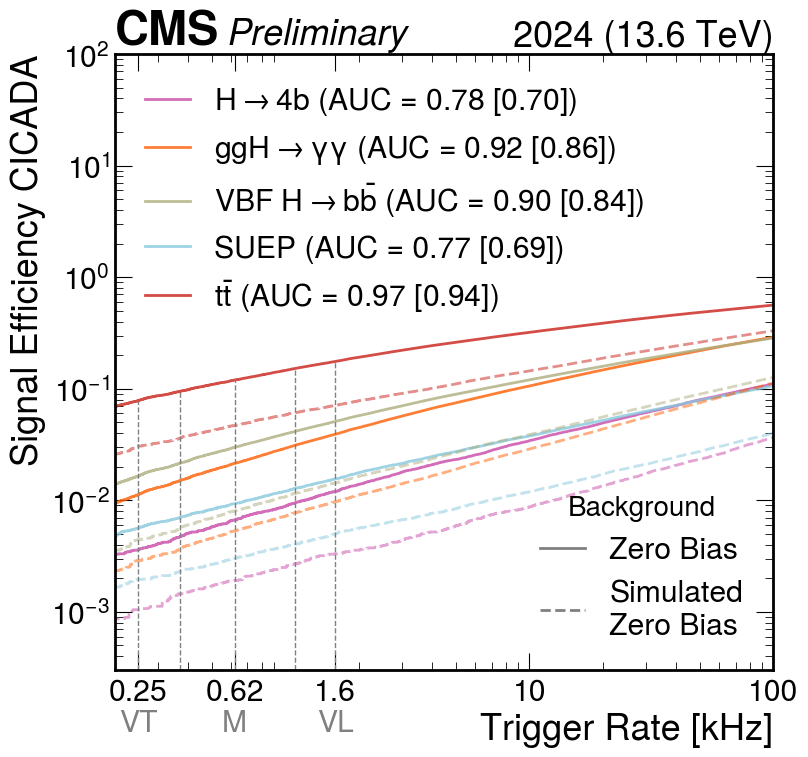

Working point VL at rate 1.6 kHz with TPR 0.10
Working point  at rate 1.1 kHz with TPR 0.08
Working point M at rate 0.62 kHz with TPR 0.06
Working point  at rate 0.37 kHz with TPR 0.05
Working point VT at rate 0.25 kHz with TPR 0.04


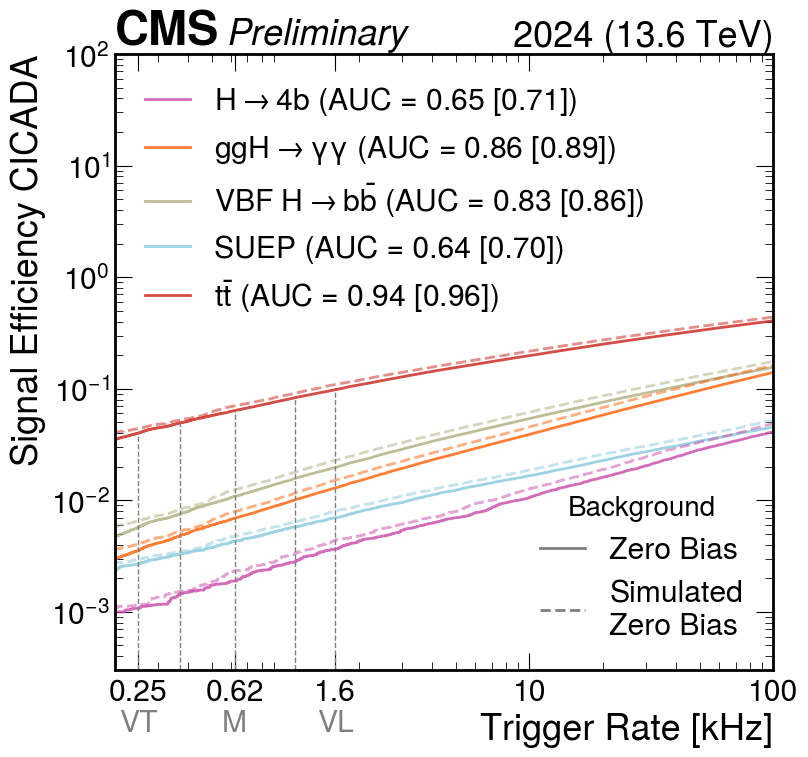

Working point VL at rate 3.8 kHz with TPR 0.36
Working point  at rate 2.2 kHz with TPR 0.30
Working point M at rate 1.5 kHz with TPR 0.26
Working point  at rate 1.1 kHz with TPR 0.23
Working point VT at rate 0.45 kHz with TPR 0.15


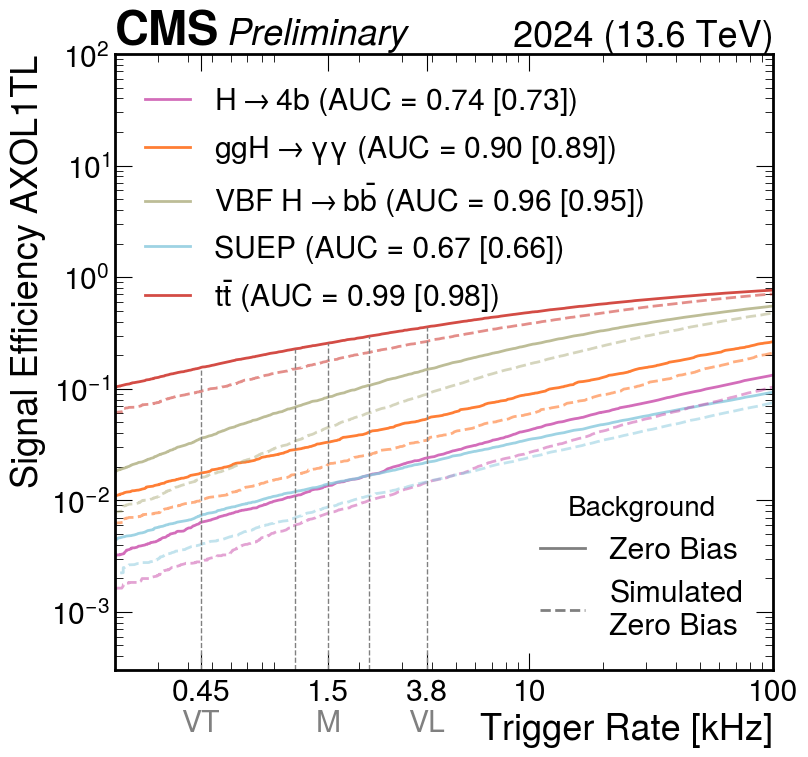

Working point VL at rate 3.8 kHz with TPR 0.34
Working point  at rate 2.2 kHz with TPR 0.28
Working point M at rate 1.5 kHz with TPR 0.24
Working point  at rate 1.1 kHz with TPR 0.22
Working point VT at rate 0.45 kHz with TPR 0.15


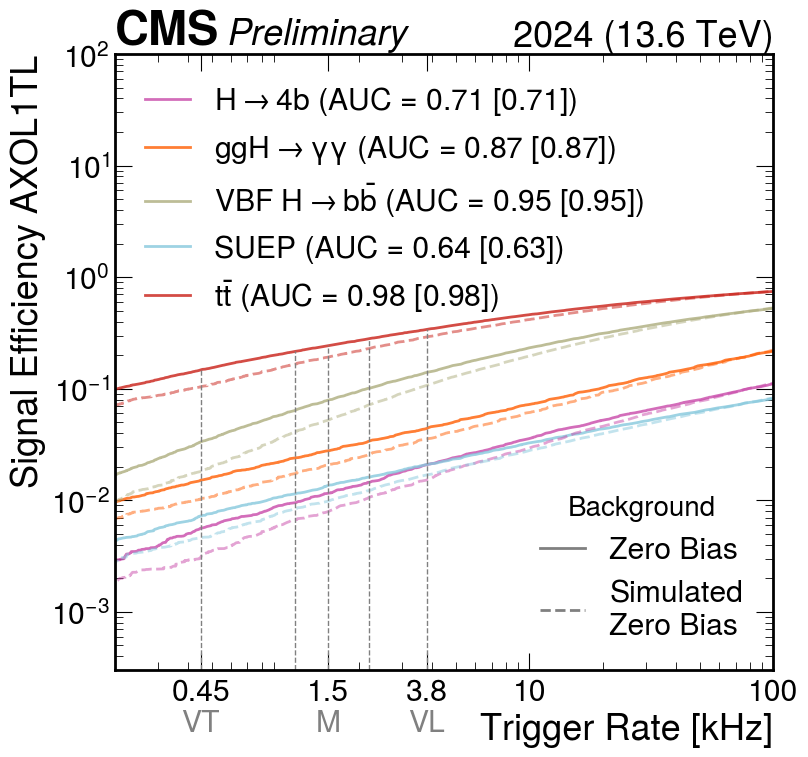

Working point VL at rate 1.6 kHz with TPR 0.01
Working point  at rate 1.1 kHz with TPR 0.01
Working point M at rate 0.62 kHz with TPR 0.00
Working point  at rate 0.37 kHz with TPR 0.00
Working point VT at rate 0.25 kHz with TPR 0.00


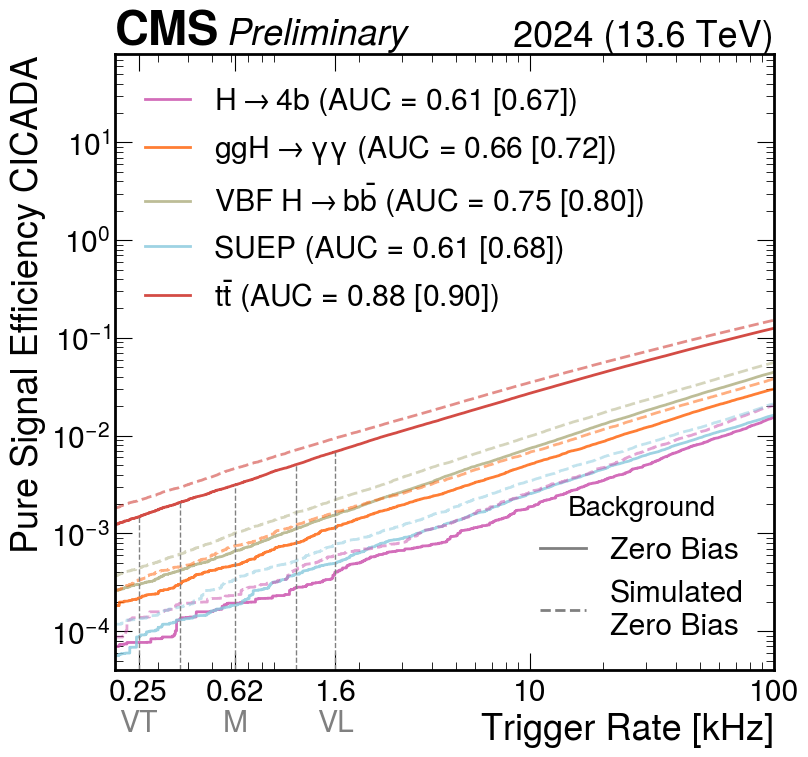

Working point VL at rate 3.8 kHz with TPR 0.12
Working point  at rate 2.2 kHz with TPR 0.08
Working point M at rate 1.5 kHz with TPR 0.06
Working point  at rate 1.1 kHz with TPR 0.05
Working point VT at rate 0.45 kHz with TPR 0.03


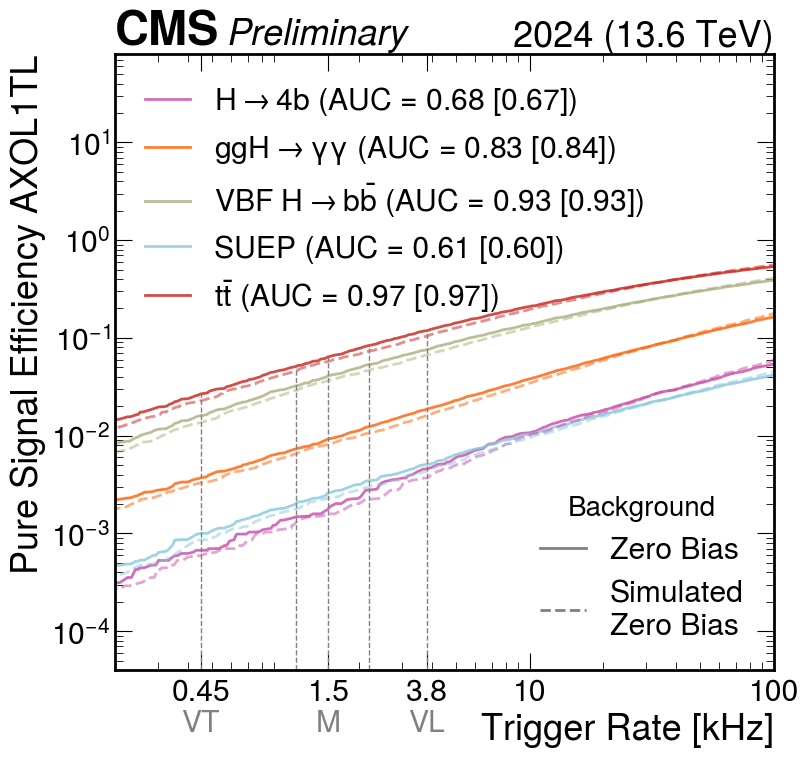

In [ ]:
importlib.reload(drawing)
draw = drawing.Draw(interactive=True, output_format="pdf")

draw.plot_roc_curves(
    roc_dict_cicada,
    roc_dict_alt=roc_dict_cicada_baseline,
    alt_legend=("Background", ("Zero Bias", "Simulated\nZero Bias")),
    yrange=(0.0003, 100),
    xrange=(0.2, 100),
    working_points=((1.6, "VL"), (1.1, ""), (0.62, "M"), (0.37, ""), (0.25, "VT")),
    ylabel="Signal Efficiency CICADA",
    figsize=(8.5, 8),
    name="roc-cicada",
)

draw.plot_roc_curves(
    roc_dict_cicada_rw,
    roc_dict_alt=roc_dict_cicada_baseline_rw,
    alt_legend=("Background", ("Zero Bias", "Simulated\nZero Bias")),
    yrange=(0.0003, 100),
    # yrange=(0.0002, 20),
    xrange=(0.2, 100),
    working_points=((1.6, "VL"), (1.1, ""), (0.62, "M"), (0.37, ""), (0.25, "VT")),
    ylabel="Signal Efficiency CICADA",
    figsize=(8.5, 8),
    name="roc-cicada-rw",
)

draw.plot_roc_curves(
    roc_dict_axo,
    roc_dict_alt=roc_dict_axo_baseline,
    alt_legend=("Background", ("Zero Bias", "Simulated\nZero Bias")),
    yrange=(0.0003, 100),
    xrange=(0.2, 100),
    working_points=((3.8, "VL"), (2.2, ""), (1.5, "M"), (1.1, ""), (0.45, "VT")),
    ylabel="Signal Efficiency AXOL1TL",
    figsize=(8.5, 8),
    name="roc-axo",
)

draw.plot_roc_curves(
    roc_dict_axo_rw,
    roc_dict_alt=roc_dict_axo_baseline_rw,
    alt_legend=("Background", ("Zero Bias", "Simulated\nZero Bias")),
    yrange=(0.0003, 100),
    xrange=(0.2, 100),
    working_points=((3.8, "VL"), (2.2, ""), (1.5, "M"), (1.1, ""), (0.45, "VT")),
    ylabel="Signal Efficiency AXOL1TL",
    figsize=(8.5, 8),
    name="roc-axo-rw",
)

draw.plot_roc_curves(
    roc_dict_cicada_pure_rw,
    roc_dict_alt=roc_dict_cicada_baseline_pure_rw,
    alt_legend=("Background", ("Zero Bias", "Simulated\nZero Bias")),
    yrange=(0.00004, 80),
    # yrange=(0.0002, 20),
    xrange=(0.2, 100),
    working_points=((1.6, "VL"), (1.1, ""), (0.62, "M"), (0.37, ""), (0.25, "VT")),
    ylabel="Pure Signal Efficiency CICADA",
    figsize=(8.5, 8),
    name="roc-cicada-pure-rw",
)

draw.plot_roc_curves(
    roc_dict_axo_pure_rw,
    roc_dict_alt=roc_dict_axo_baseline_pure_rw,
    alt_legend=("Background", ("Zero Bias", "Simulated\nZero Bias")),
    yrange=(0.00004, 80),
    xrange=(0.2, 100),
    working_points=((3.8, "VL"), (2.2, ""), (1.5, "M"), (1.1, ""), (0.45, "VT")),
    ylabel="Pure Signal Efficiency AXOL1TL",
    figsize=(8.5, 8),
    name="roc-axo-v4-pure-rw",
)

In [21]:
npv_good = get_array("ZB", "PV_npvsGood")
cicada_score = get_array("ZB", "CICADA2024_CICADAScore")
teacher_score = get_array("ZB", "CICADA2024_TeacherScore")
teacher_score = utils.quantize(teacher_score)
is_pure = get_array("ZB", "is_pure")

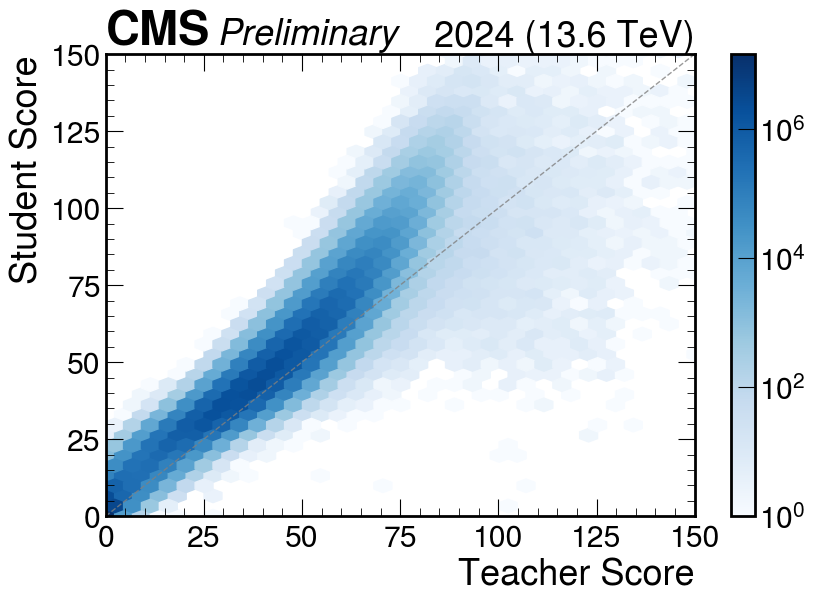

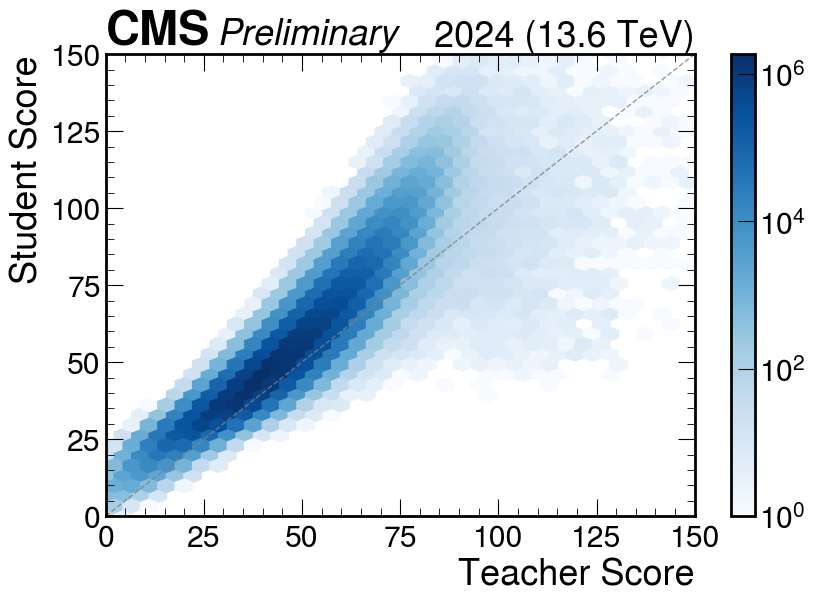

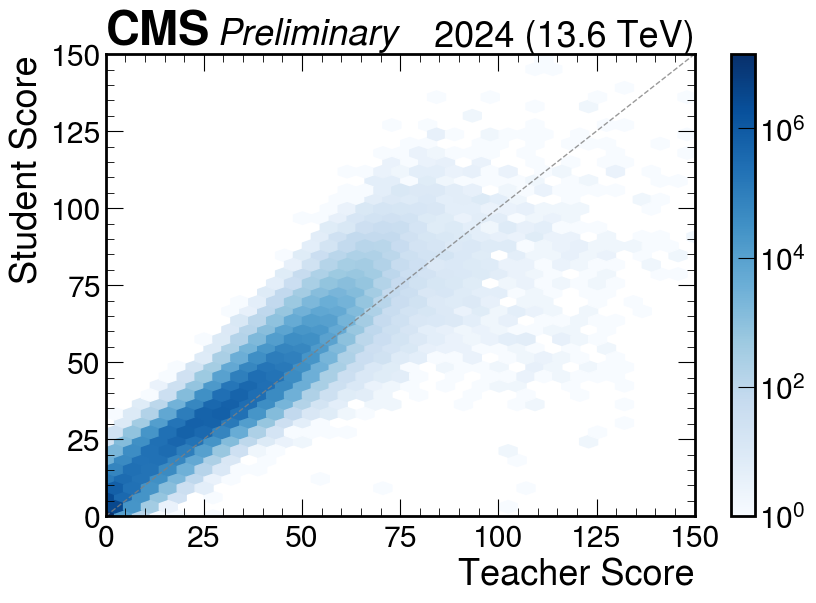

In [22]:
importlib.reload(drawing)
draw = drawing.Draw(interactive=True, )

draw.make_teacher_student_scatter_plot(
    teacher_score,
    cicada_score,
    name="cicada_vs_teacher_score",
)

npv_mask = npv_good > 30
draw.make_teacher_student_scatter_plot(
    teacher_score[npv_mask],
    cicada_score[npv_mask],
    name="cicada_vs_teacher_score_npv_over",
)

npv_mask = npv_good <= 30
draw.make_teacher_student_scatter_plot(
    teacher_score[npv_mask],
    cicada_score[npv_mask],
    name="cicada_vs_teacher_score_npv_under",
)


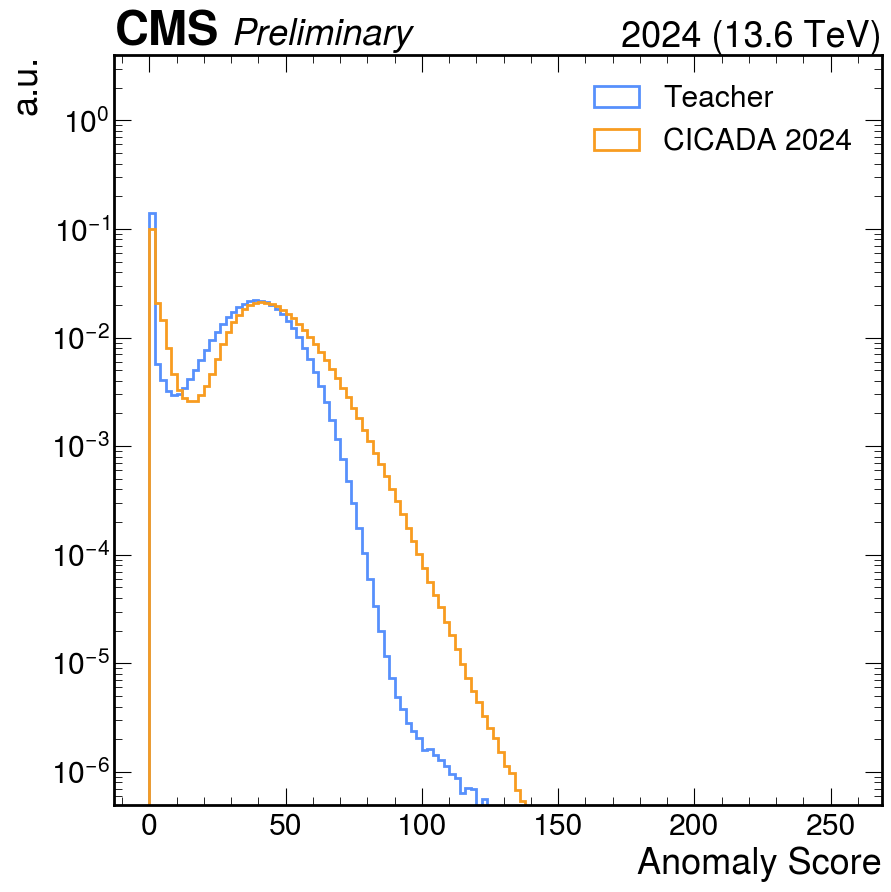

In [23]:
importlib.reload(drawing)
draw = drawing.Draw(interactive=True)

draw.plot_anomaly_score_distribution(
    [teacher_score, cicada_score],
    name="score-dist-teacher-and-student",
    xlabel="Anomaly Score",
    labels=["Teacher", "CICADA 2024"],
    # colors=[]
)